In [1]:
import os
import random
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.datasets import STL10
from pathlib import Path
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-3
IMAGE_SIZE = 96
NUM_CLASSES = 10
DATA_LIMIT = 50000

DATA_ROOT = Path('./data')
DATA_ROOT.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Data limit: {DATA_LIMIT} images")

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

train_full = STL10(root=DATA_ROOT, split='train', transform=transform, download=True)
test_full = STL10(root=DATA_ROOT, split='test', transform=transform, download=True)

TRAIN_SIZE = min(40000, len(train_full))
TEST_SIZE = min(10000, len(test_full))

train_dataset = Subset(train_full, range(TRAIN_SIZE))
test_dataset = Subset(test_full, range(TEST_SIZE))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

Device: cuda
Data limit: 50000 images


100%|██████████| 2.64G/2.64G [01:27<00:00, 30.0MB/s]


Train: 5000 | Test: 8000
Batches per epoch: 157


In [2]:
DEVICE

'cuda'

In [3]:
def feature_map(x):
    return F.elu(x) + 1.0

class VanillaLinearAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.out = nn.Linear(dim, dim, bias=False)

    def forward(self, x):
        B, T, _ = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q, k, v = feature_map(q), feature_map(k), v

        kv = torch.einsum('btd,bte->bde', k, v)
        z = torch.einsum('btd,btd->bt', q, k)
        out = torch.einsum('btd,bde->bte', q, kv)
        return self.out(out / (z.unsqueeze(-1) + 1e-6))

class ZeroSAttention(nn.Module):
    def __init__(self, dim, num_heads=1, use_cos_theta=True, bias=False):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.use_cos_theta = use_cos_theta

        self.qkv = nn.Linear(dim, 3 * dim, bias=bias)
        self.gate1 = nn.Linear(dim, num_heads, bias=bias)
        self.gateh = nn.Linear(dim, num_heads, bias=bias)
        self.out = nn.Linear(dim, dim, bias=bias)

    def forward(self, x):
        B, T, D = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        s = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        a = F.softmax(s, dim=-1)

        u = 1.0 / T
        s_mean = s.mean(dim=-1, keepdim=True)
        delta = (s - s_mean) / T
        eps = a - u - delta

        g1 = torch.sigmoid(self.gate1(x)).permute(0, 2, 1).unsqueeze(-1)
        gh = torch.sigmoid(self.gateh(x)).permute(0, 2, 1).unsqueeze(-1)

        w = g1 * delta + gh * eps

        if self.use_cos_theta:
            q_n = F.normalize(q, dim=-1)
            k_n = F.normalize(k, dim=-1)
            cos_t = torch.matmul(q_n, k_n.transpose(-2, -1))
            w = w * cos_t

        out = torch.matmul(w, v)
        out = out.transpose(1, 2).reshape(B, T, D)
        return self.out(out)

In [5]:
class PatchAttentionClassifier(nn.Module):
    def __init__(self, in_channels=3, num_classes=10, embed_dim=64, patch_size=12, num_heads=4, attention_type='vanilla'):
        super().__init__()
        assert IMAGE_SIZE % patch_size == 0, "patch_size must divide IMAGE_SIZE"
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.attention_type = attention_type

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.GELU()
        )

        if attention_type == 'vanilla':
            self.attn = VanillaLinearAttention(embed_dim)
        elif attention_type == 'zeros':
            self.attn = ZeroSAttention(embed_dim, num_heads=num_heads)
        else:
            raise ValueError(f"Unknown attention type: {attention_type}")

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.stem(x)
        B, D, Ph, Pw = x.shape
        x = x.permute(0, 2, 3, 1).reshape(B, -1, D)
        x = self.attn(x)
        x = x.mean(dim=1)
        return self.head(x)

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred = logits.argmax(dim=1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    return total_loss / len(loader), correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item()
        pred = logits.argmax(dim=1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    return total_loss / len(loader), correct / total

def run_experiment(attention_type, num_heads=4, epochs=EPOCHS, lr=LR, device=DEVICE):
    print(f"--- Training {attention_type.upper()} ---")
    model = PatchAttentionClassifier(
        in_channels=3, num_classes=NUM_CLASSES, embed_dim=64,
        patch_size=12, num_heads=num_heads, attention_type=attention_type
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_acc': [], 'val_loss': []}
    best_acc = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v_loss, v_acc = evaluate(model, test_loader, criterion, device)
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        if v_acc > best_acc:
            best_acc = v_acc
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 5 == 0 or epoch == 1:
            print(f"Ep {epoch:02d}/{epochs} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.4f}")

    model.load_state_dict(best_state)
    return model, history, best_acc

In [9]:
results = {}
EPOCHS_RUN = 50

print("=== Запуск VANILLA Linear Attention ===")
model_v, hist_v, best_v = run_experiment('vanilla', num_heads=4, epochs=EPOCHS_RUN)
results['vanilla'] = {'history': hist_v, 'best_acc': best_v}

print("\n=== Запуск ZeroS ===")
model_z, hist_z, best_z = run_experiment('zeros', num_heads=4, epochs=EPOCHS_RUN)
results['zeros'] = {'history': hist_z, 'best_acc': best_z}

print("\n--- СВОДКА ---")
print(f"Vanilla Best Acc: {best_v:.4f}")
print(f"ZeroS   Best Acc: {best_z:.4f}")
print(f"Delta (ZeroS - Vanilla): {(best_z - best_v):+.4f}")

=== Запуск VANILLA Linear Attention ===
--- Training VANILLA ---
Ep 01/50 | Train Loss: 1.9747 | Val Loss: 1.8328 | Val Acc: 0.2959
Ep 05/50 | Train Loss: 1.6789 | Val Loss: 1.6797 | Val Acc: 0.3669
Ep 10/50 | Train Loss: 1.5593 | Val Loss: 1.6227 | Val Acc: 0.3836
Ep 15/50 | Train Loss: 1.4808 | Val Loss: 1.5694 | Val Acc: 0.4138
Ep 20/50 | Train Loss: 1.4264 | Val Loss: 1.5542 | Val Acc: 0.4155
Ep 25/50 | Train Loss: 1.3721 | Val Loss: 1.5136 | Val Acc: 0.4369
Ep 30/50 | Train Loss: 1.3035 | Val Loss: 1.5253 | Val Acc: 0.4349
Ep 35/50 | Train Loss: 1.2435 | Val Loss: 1.5674 | Val Acc: 0.4280
Ep 40/50 | Train Loss: 1.1885 | Val Loss: 1.5472 | Val Acc: 0.4330
Ep 45/50 | Train Loss: 1.1353 | Val Loss: 1.5824 | Val Acc: 0.4339
Ep 50/50 | Train Loss: 1.0660 | Val Loss: 1.6690 | Val Acc: 0.4313

=== Запуск ZeroS ===
--- Training ZEROS ---
Ep 01/50 | Train Loss: 1.9507 | Val Loss: 1.8411 | Val Acc: 0.2984
Ep 05/50 | Train Loss: 1.6317 | Val Loss: 1.6626 | Val Acc: 0.3713
Ep 10/50 | Train Lo

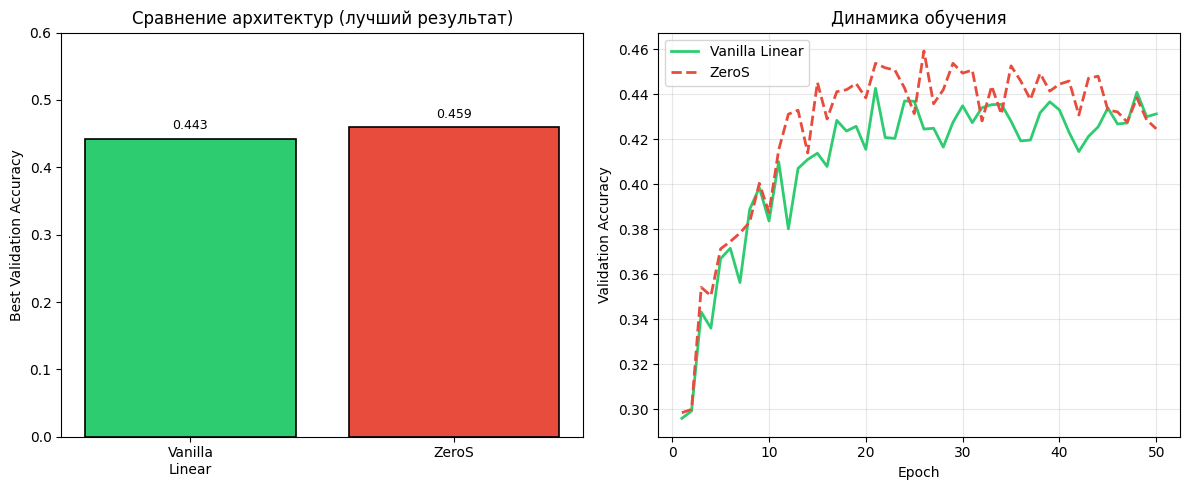

Метрика                   Vanilla Linear  ZeroS          
-------------------------------------------------------
Best Accuracy             0.4426        0.4592
Final Accuracy            0.4313        0.4246
Final Train Loss          1.0660        0.7537
Params Count              44938        45450


In [11]:
epochs = range(1, EPOCHS_RUN + 1)
hist_v = results['vanilla']['history']
hist_z = results['zeros']['history']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
models = ['Vanilla\nLinear', 'ZeroS']
best_accs = [results['vanilla']['best_acc'], results['zeros']['best_acc']]
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(models, best_accs, color=colors, edgecolor='black', linewidth=1.2)
plt.ylabel('Best Validation Accuracy')
plt.title('Сравнение архитектур (лучший результат)')
plt.ylim(0, 0.6)
for bar, acc in zip(bars, best_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.subplot(1, 2, 2)
plt.plot(epochs, hist_v['val_acc'], label='Vanilla Linear', color=colors[0], linewidth=2)
plt.plot(epochs, hist_z['val_acc'], label='ZeroS', color=colors[1], linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Динамика обучения')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'Метрика':<25} {'Vanilla Linear':<15} {'ZeroS':<15}")
print("-" * 55)
print(f"{'Best Accuracy':<25} {results['vanilla']['best_acc']:.4f}        {results['zeros']['best_acc']:.4f}")
print(f"{'Final Accuracy':<25} {hist_v['val_acc'][-1]:.4f}        {hist_z['val_acc'][-1]:.4f}")
print(f"{'Final Train Loss':<25} {hist_v['train_loss'][-1]:.4f}        {hist_z['train_loss'][-1]:.4f}")
print(f"{'Params Count':<25} {params_v}        {params_z}")

In [12]:

"""
Вывод:
ZeroS показал себя чуть лучше чем классический attention и даже чуть лучше чем MHLA Из прошлой дз
Используя этот подход, можно за счёт способности явно подавлять шум через отрицательные веса - выиграть пару процентов метрики на нашей задаче
Так что берем на вооружение еще +1 интересный подход.


"""

'\nВывод:\nZeroS показал себя чуть лучше чем классический attention и даже чуть лучше чем MHLA Из прошлой дз\nИспользуя этот подход, можно за счёт способности явно подавлять шум через отрицательные веса - выиграть пару процентов метрики на нашей задаче\nТак что берем на вооружение еще +1 интересный подход.\n\n\n'